# MSTS Code Along (Part2): Improving Our Basic Momentum Portfolio
*Sep 2025*

---

## Introduction

This notebook builds on our previous work with momentum strategies. We'll address key limitations and introduce enhancements to make our portfolio more robust and realistic.

**Today's agenda:**
1. **Recap:** Review the simple momentum model and its performance.
2. **Breadth:** Expand the investable universe beyond the S&P 500.
3. **Ex-Ante Measurment:** Improve beta measurement and hedging (ex-post vs. ex-ante).
4. **Bias Control:** Identify and remove sector biases via sector-neutralization.

Let's get started!

---

## Imports

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_flavor as pf

# Enable autoreload for development
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Use absolute import instead of relative import
import sys
sys.path.append("../") # Add parent directory to path

In [2]:
# Imports from helpers
from helpers import charting_functions as ch
from helpers.data_functions import *
from helpers.signal_functions import *
from helpers.position_functions import *
from helpers.performance_functions import performance_summary

---

## 1. Recap: Simple Momentum Model
Let's briefly review what we did last time:
- Built a simple momentum strategy using 500 S&P stocks
- Generated signals based on 1-year returns
- Constructed portfolios with basic risk controls
- Evaluated performance and identified limitations
 
We'll use this as our baseline for improvements.

### Returns, Scores, and Signal Generation

In [3]:
# Load price and sector data for S&P 500 universe
px_last = pd.read_csv(rf'../data/PX_LAST.csv', index_col=0, parse_dates=True)
 
# Compute daily returns
df_orig_returns_raw = px_last.ffill().pct_change(periods=1, fill_method=None)
 
# Clean returns (remove outliers, fill missing)
df_orig_returns = clean_returns(df_orig_returns_raw, threshold=0.75)
 
# Separate stock and market returns
df_orig_stock_returns = df_orig_returns.drop(columns='SPX Index')
df_market_returns = df_orig_returns['SPX Index']
 
# Compute 1-year (252d) rolling returns, shifted to avoid lookahead bias
df_orig_252d_stock_returns = (df_orig_stock_returns.add(1).apply(np.log)
    .rolling(window=252, min_periods=40).sum().apply(np.exp).sub(1)
    .shift(20).bfill())
 
# Generate momentum scores (z-scored, winsorized)
df_orig_stock_mom_score = df_orig_252d_stock_returns.winsorize(percentile=0.01, axis=1).zstandardize(axis=1)
 
# Generate trading signals (linear capped, lagged)
df_orig_signal = df_orig_stock_mom_score.linear_capped_signals(lower_pct=0.05, upper_pct=0.95).shift(1)

### Portfolio Construction: Baseline

In [4]:
# Build baseline momentum portfolios with different risk controls
df_orig_momentum_positions = pd.concat({
    'Raw': position_function(
        df_orig_signal, df_orig_stock_returns, df_market_returns, 
        target_vol=0.1, dollar_neutral=False, beta_neutral=False, # No neutrality
        max_gearing=None, max_posn=None, window=40
    ),
    'Dollar Neutral': position_function(
        df_orig_signal, df_orig_stock_returns, df_market_returns, 
        target_vol=0.1, dollar_neutral=True, beta_neutral=False, # Dollar neutral only
        max_gearing=None, max_posn=None, window=40
    ),
    'Beta Neutral': position_function(
        df_orig_signal, df_orig_stock_returns, df_market_returns, 
        target_vol=0.1, dollar_neutral=True, beta_neutral=True, # Dollar + beta neutral
        max_gearing=None, max_posn=None, window=40
    ),
    'Beta Neutral + Max Lev': position_function(
        df_orig_signal, df_orig_stock_returns, df_market_returns, 
        target_vol=0.1, dollar_neutral=True, beta_neutral=True, 
        max_gearing=1.25, max_posn=0.03, window=40 # Add leverage and position limits
    )
}, axis=1, names=['portfolio', 'security'])
 
# Compute portfolio returns
df_orig_momentum_rets = pd.DataFrame()
for pf in df_orig_momentum_positions.columns.get_level_values('portfolio').unique():
    df_orig_momentum_rets[pf] = df_orig_momentum_positions[pf].get_portfolio_returns(df_orig_returns)
 
# Add market returns (volatility adjusted) for comparison
df_mkt_vol_adj_rets = df_market_returns.mul(0.1 / (df_market_returns.std() * (np.sqrt(252))))
df_orig_portfolios_rets = pd.concat([df_orig_momentum_rets, df_mkt_vol_adj_rets], axis=1).loc['2018-03':]

### Performance Appraisal: Baseline

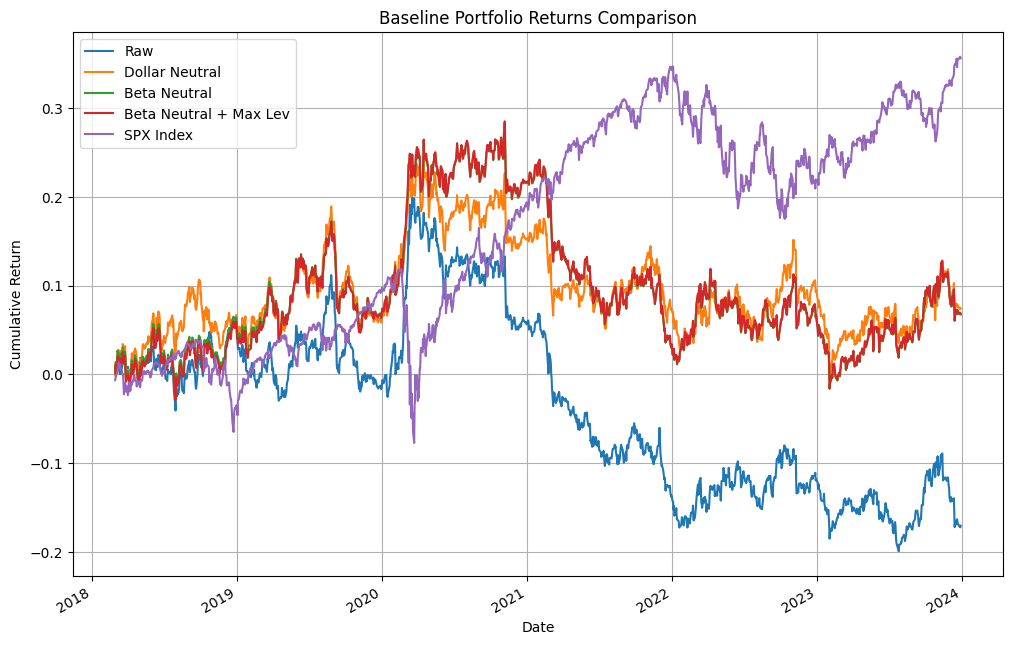

In [5]:
# Plot cumulative returns for baseline portfolios
df_orig_portfolios_rets.add(1).cumprod().sub(1)\
    .plot(figsize=(12, 8),
          title='Baseline Portfolio Returns Comparison',
          xlabel='Date',
          ylabel='Cumulative Return',
          grid=True)
plt.show()

In [6]:
# Show performance summary table for baseline portfolios
performance_summary(df_orig_portfolios_rets, 252, risk_free_rate=0.0, benchmark_r=df_market_returns)

,Raw,Dollar Neutral,Beta Neutral,Beta Neutral + Max Lev,SPX Index
Annualized Return,-0.03149,0.012328,0.011257,0.011396,0.053577
Annualized Volatility,0.109131,0.108333,0.107189,0.106761,0.10011
Skewness,-0.523321,-0.908807,-0.80548,-0.798008,-0.482711
Kurtosis,7.49587,7.614403,7.376897,7.374995,15.911825
Is Normal,False,False,False,False,False
Sharpe Ratio,-0.28855,0.113796,0.105022,0.106744,0.535181
Beta to Benchmark,-0.260369,-0.018827,-0.026464,-0.02634,0.48516
Correlation to Benchmark,-0.492303,-0.035859,-0.050943,-0.050908,1.0
Monthly Historic VaR (95%),0.011364,0.011596,0.011238,0.011238,0.009299
Monthly Historic CVaR (95%),0.015629,0.016407,0.01631,0.016221,0.015244


---

## 2. Breadth: Expanding the Investable Universe
Now, let's expand our universe beyond the S&P 500 to include more stocks.

### Compare Universes

In [7]:
# Load returns for expanded universe
df_stock_returns_raw = pd.read_csv(rf'../data/UNIV_RETS.csv', index_col=0, header=[0,1], parse_dates=True)
 
# Clean returns and align with market returns
df_stock_returns = clean_returns(df_stock_returns_raw.droplevel(['SECTOR'], axis=1).rename_axis(None, axis=1), threshold=0.75)
df_returns = pd.concat([df_stock_returns, df_market_returns], axis=1)

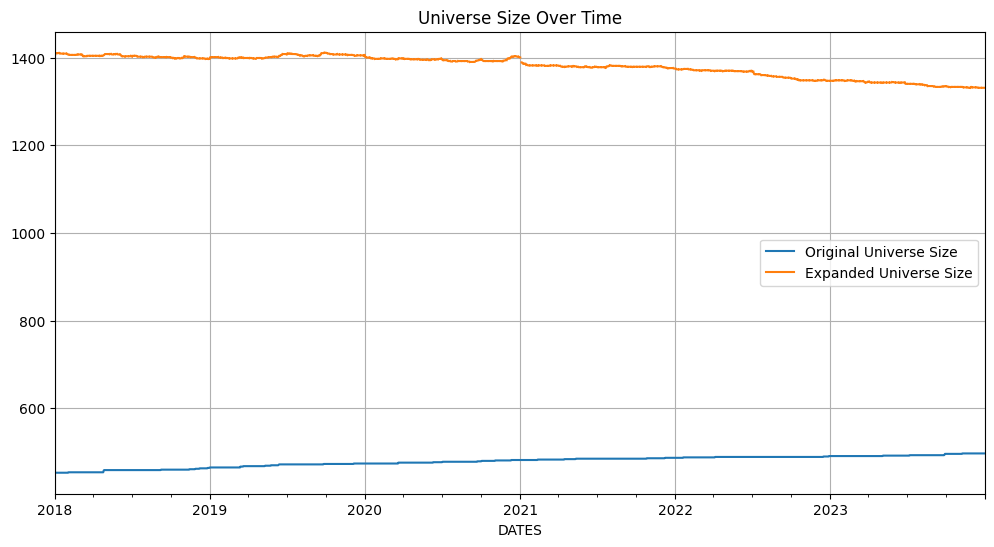

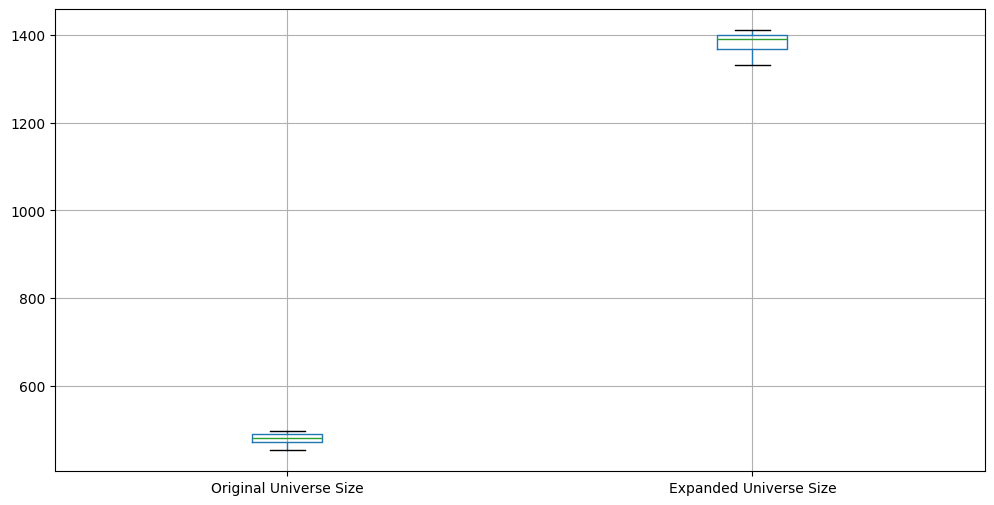

In [8]:
df_universe_count = pd.concat([df_orig_returns_raw.count(axis=1).replace(0.0, np.nan).dropna().rename("Original Universe Size"),
                               df_stock_returns_raw.count(axis=1).replace(0.0, np.nan).dropna().rename("Expanded Universe Size")], axis=1)
df_universe_count.plot(figsize=(12, 6), title='Universe Size Over Time', grid=True)
plt.show()
df_universe_count.boxplot(figsize=(12, 6),grid=True)
plt.show()

### Returns, Scores, and Signal Generation
Let's repeat the signal generation process for the larger universe.

In [9]:
# Compute 1-year rolling returns, shifted
df_252d_stock_returns = (df_stock_returns.add(1).apply(np.log)
    .rolling(window=252, min_periods=40).sum().apply(np.exp).sub(1)
    .shift(20).bfill())
 
# Generate momentum scores and signals
df_stock_mom_score = df_252d_stock_returns.winsorize(percentile=0.01, axis=1).zstandardize(axis=1)
df_signal = df_stock_mom_score.linear_capped_signals(lower_pct=0.05, upper_pct=0.95).shift(1)

### Portfolio Construction: Breadth

In [10]:
# Build portfolios: original vs expanded universe
df_breadth_positions = pd.concat({
    'S&P 500': df_orig_momentum_positions['Beta Neutral'],
    'Expanded': position_function(
        df_signal, df_stock_returns, df_market_returns, 
        target_vol=0.1, dollar_neutral=True, beta_neutral=True, 
        max_gearing=1.25, max_posn=None, window=40
    )
}, axis=1, names=['portfolio', 'security'])
 
# Compute returns for each portfolio
df_breadth_rets = pd.DataFrame()
rets_dict = {'S&P 500': df_orig_returns, 'Expanded': df_returns}
for pf in df_breadth_positions.columns.get_level_values('portfolio').unique():
    df_breadth_rets[pf] = df_breadth_positions[pf].get_portfolio_returns(rets_dict[pf])

df_breadth_rets = pd.concat([df_breadth_rets, df_mkt_vol_adj_rets], axis=1).loc['2018-03':]

### Performance Appraisal: Breadth

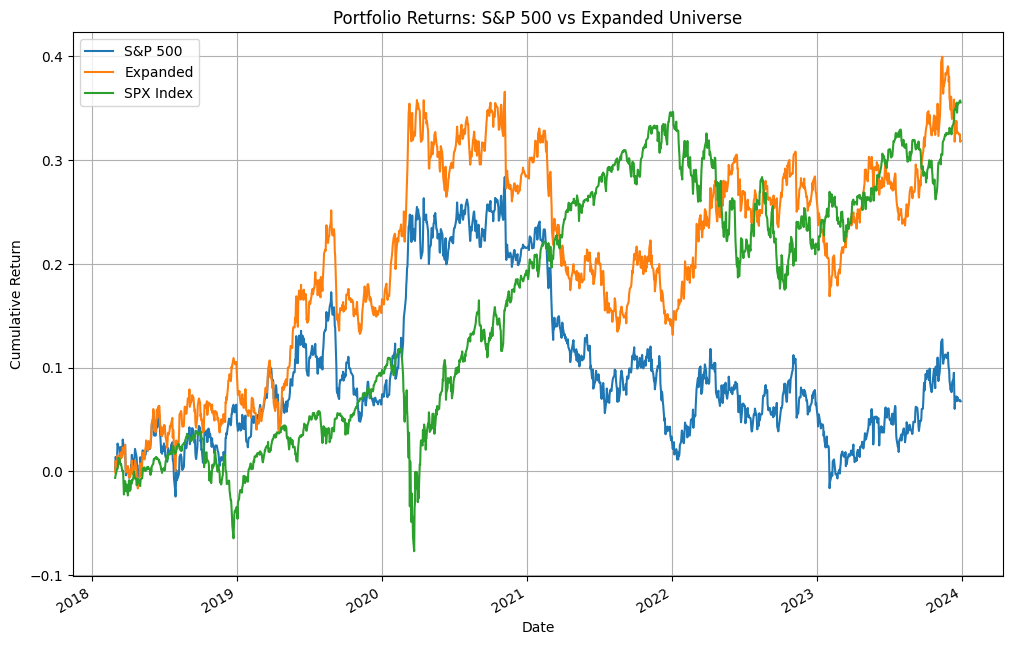

In [11]:
# Plot cumulative returns: original vs expanded universe
df_breadth_rets.add(1).cumprod().sub(1).ffill()\
    .plot(figsize=(12, 8),
          title='Portfolio Returns: S&P 500 vs Expanded Universe',
          xlabel='Date',
          ylabel='Cumulative Return',
          grid=True)
plt.show()

In [12]:
# Show performance summary for both universes
performance_summary(df_breadth_rets, 252, risk_free_rate=0.0, benchmark_r=df_market_returns)

,S&P 500,Expanded,SPX Index
Annualized Return,0.010972,0.047328,0.052191
Annualized Volatility,0.105828,0.107753,0.10011
Skewness,-0.815065,-0.720343,-0.482711
Kurtosis,7.566854,8.761751,15.911825
Is Normal,False,False,False
Sharpe Ratio,0.103675,0.439232,0.52134
Beta to Benchmark,-0.026464,-0.019815,0.48516
Correlation to Benchmark,-0.050943,-0.037466,1.0
Monthly Historic VaR (95%),0.011168,0.011493,NaN
Monthly Historic CVaR (95%),0.016175,0.015549,NaN


---

## 3. Beta: Ex-Ante vs. Ex-Post Measurement
Next, we'll improve our beta measurement and hedging. We'll compare ex-post (i.e. rolling regression) with ex-ante (i.e. bottoms-up) approaches.

### Ex-Post Beta (Rolling Regression)

<Axes: title={'center': 'Rolling Beta (50-day window)'}, xlabel='DATES'>

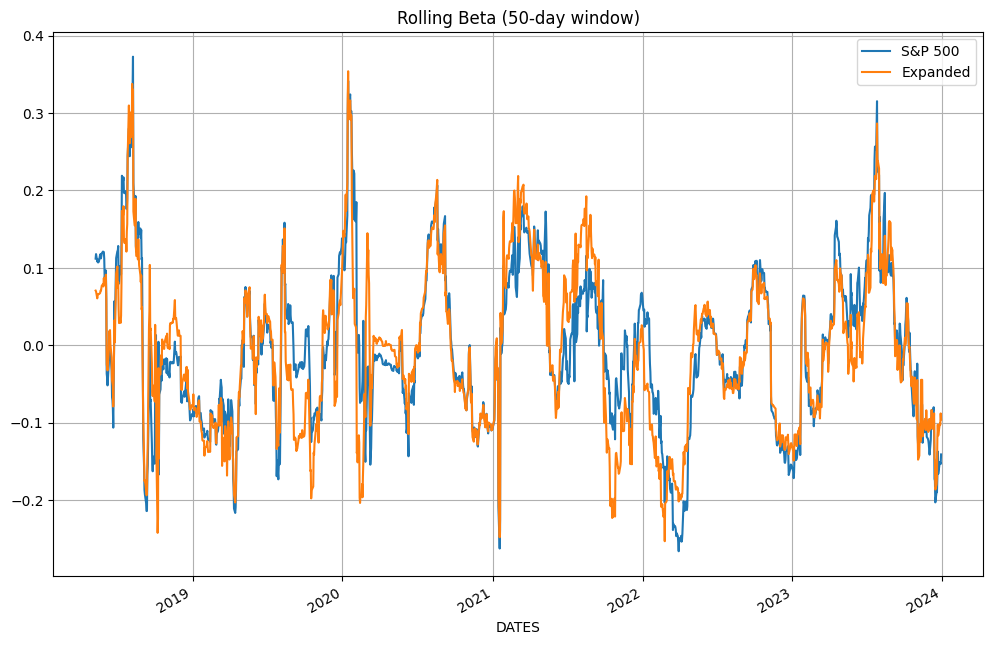

In [13]:
# Plot rolling beta (50-day window) for each portfolio
df_breadth_rets.drop('SPX Index', axis=1).apply(lambda x: x.get_portfolio_rolling_beta(df_market_returns, window=50)).plot(
    figsize=(12, 8), grid=True, title='Rolling Beta (50-day window)')

<Axes: title={'center': 'Rolling Beta of Expanded Universe Portfolio'}, xlabel='Date', ylabel='Beta'>

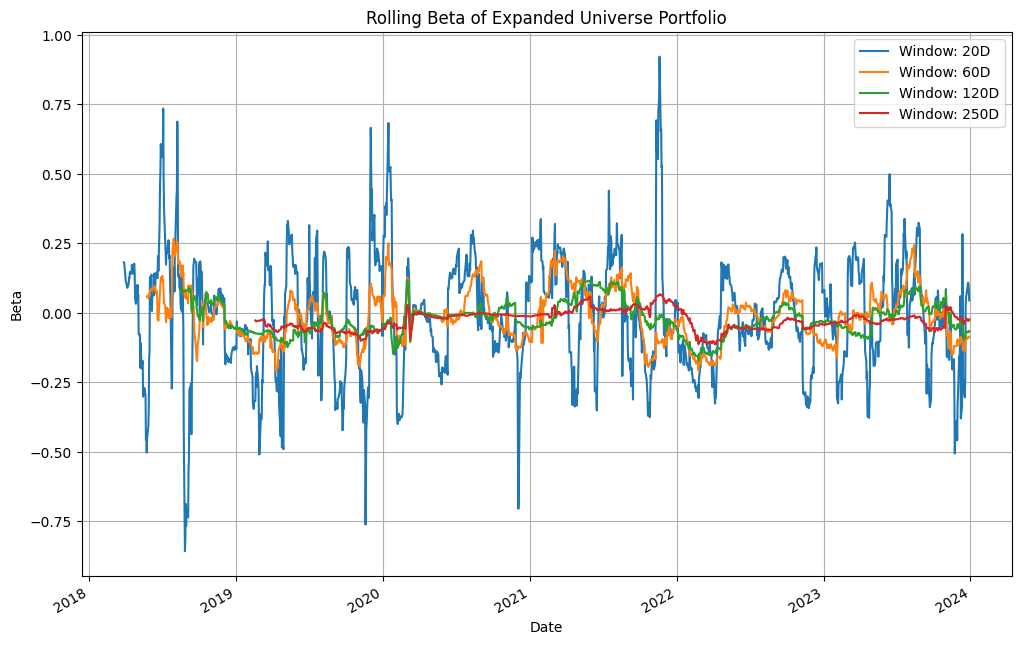

In [14]:
# Compare rolling beta with different window lengths
windows = [20, 60, 120, 250]
pf_ret = df_breadth_rets['Expanded']
pf_posn = df_breadth_positions['Expanded']
mkt_ret = df_market_returns
 
rolling_beta = pd.DataFrame()
for window in windows:
    rolling_beta[f'Window: {window}D'] = pf_ret.get_portfolio_rolling_beta(mkt_ret, window=window)
 
rolling_beta.plot(figsize=(12, 8), title='Rolling Beta of Expanded Universe Portfolio', xlabel='Date', ylabel='Beta', grid=True)

### Ex-Ante Beta (Bottoms Up)

In [15]:
# Load ex-ante betas for each stock
df_stock_betas_raw = pd.read_csv(rf'../data/UNIV_BETAS.csv', index_col=0, header=[0,1], parse_dates=True)
df_stock_betas = df_stock_betas_raw.droplevel(['SECTOR'], axis=1).rename_axis(None, axis=1)[df_stock_returns.columns]
df_betas = df_stock_betas.copy()
df_betas['SPX Index'] = 1.0

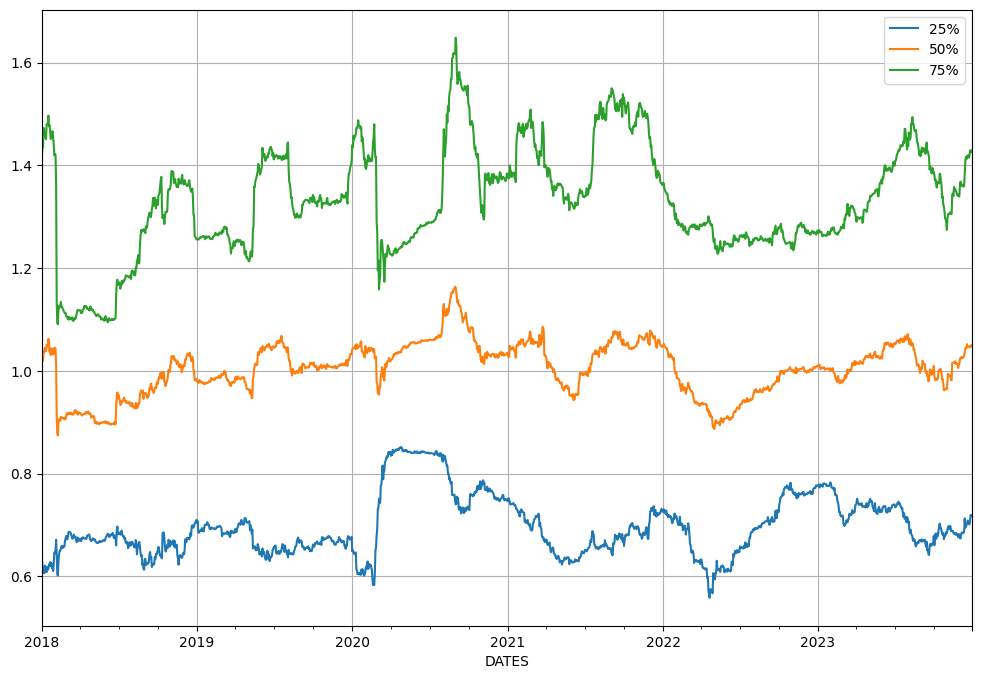

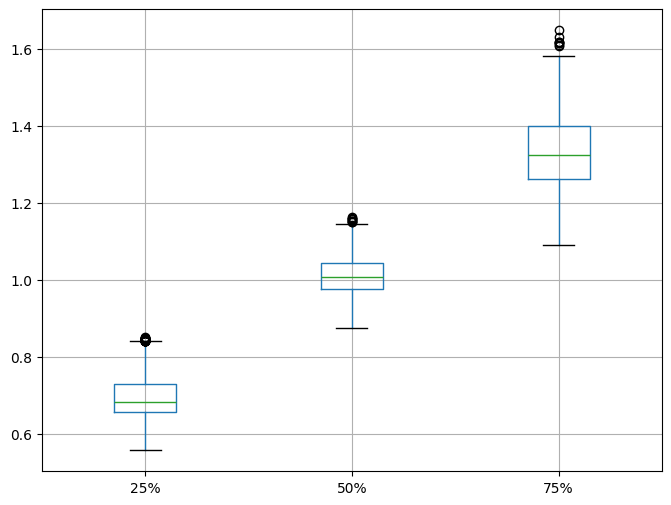

In [16]:
# Visualize distribution of ex-ante betas
betas_IQR = df_stock_betas.T.describe().T[['25%', '50%', '75%']]
betas_IQR.plot(figsize=(12,8), grid=True)
plt.show()
betas_IQR.boxplot(figsize=(8, 6), grid=True)
plt.show()

<Axes: xlabel='DATES'>

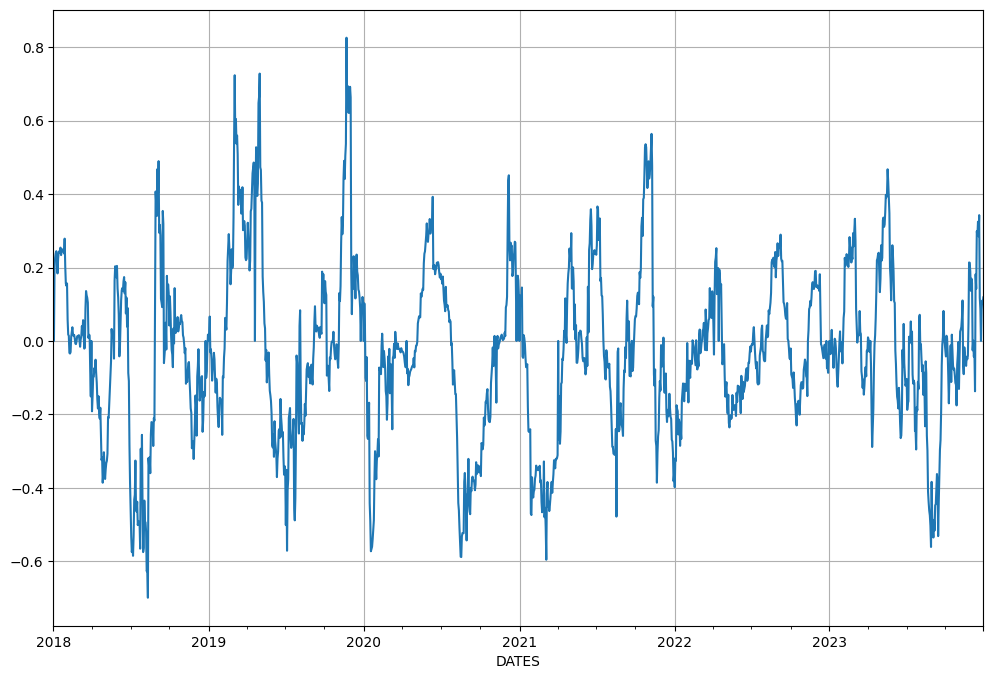

In [17]:
# Plot ex-ante beta of expanded portfolio through time
pf_posn.get_portfolio_exante_beta(df_betas).plot(figsize=(12,8), grid=True)

### Portfolio Construction: Ex-Ante
Let's compare portfolio construction and performance using ex-ante vs. ex-post beta.

In [18]:
# Build portfolios using ex-ante and ex-post beta
exante_beta_position = position_function(signal_df=df_signal, 
                                         returns_df=df_stock_returns, 
                                         market_returns_df=df_market_returns, 
                                         target_vol=0.1, 
                                         dollar_neutral=True, 
                                         beta_neutral=True, 
                                         max_gearing=1.25, 
                                         max_posn=None, 
                                         window=40, 
                                         beta_type='exante', 
                                         asset_betas=df_betas)
 
expost_beta_position = position_function(signal_df=df_signal, 
                                         returns_df=df_stock_returns, 
                                         market_returns_df=df_market_returns, 
                                         target_vol=0.1, 
                                         dollar_neutral=True, 
                                         beta_neutral=True, 
                                         max_gearing=1.25, 
                                         max_posn=None, 
                                         window=40, 
                                         beta_type='expost', 
                                         asset_betas=df_betas)


# Compare ex-ante and ex-post beta portfolios
df_exante_positions = pd.concat({'Ex-Ante': exante_beta_position,
                                 'Ex-Post': expost_beta_position
                                 }, axis=1).rename_axis(['portfolio','security'], axis=1)
 
# Compute returns for each portfolio 
df_exante_returns = pd.DataFrame()
for pf in df_exante_positions.columns.get_level_values('portfolio').unique():
    df_exante_returns[pf] = df_exante_positions[pf].get_portfolio_returns(df_returns)
df_exante_returns = df_exante_returns.loc['2018-03':]

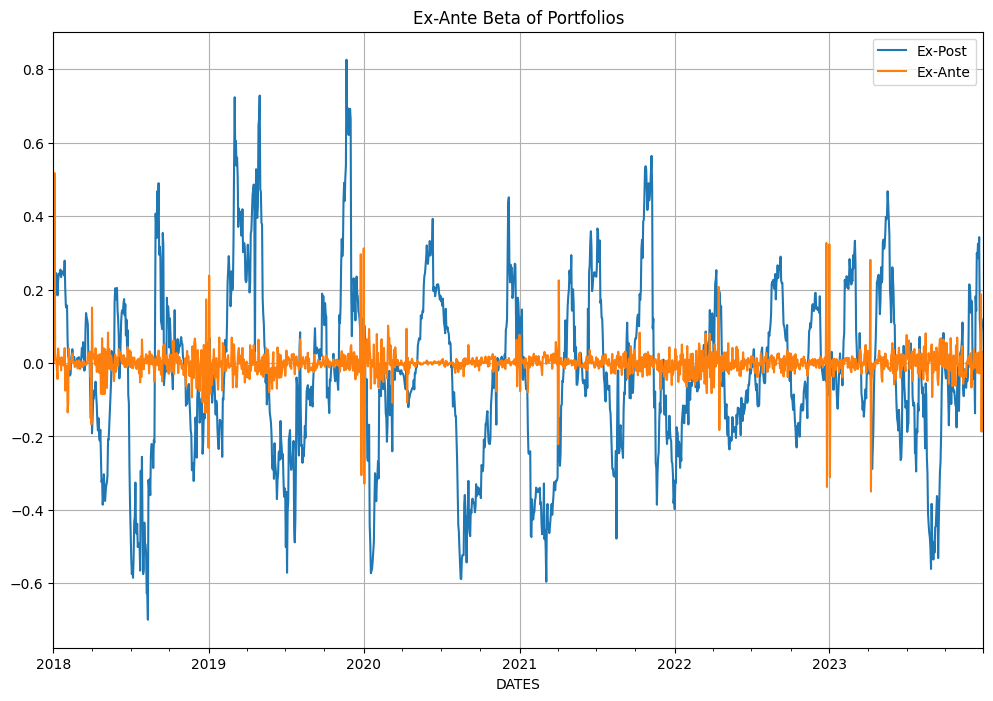

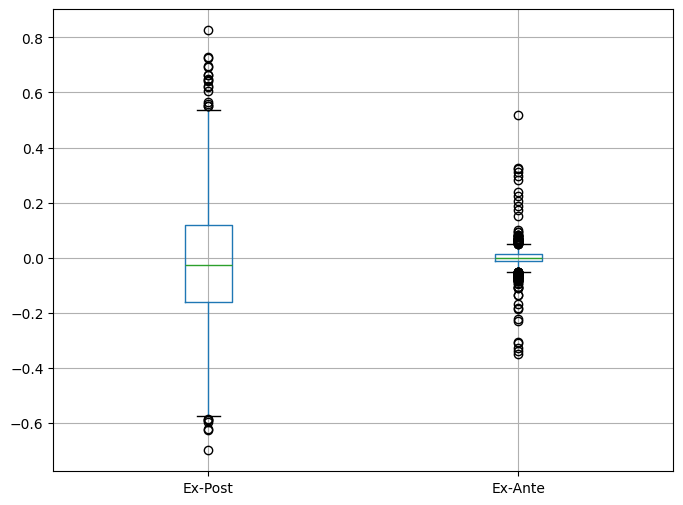

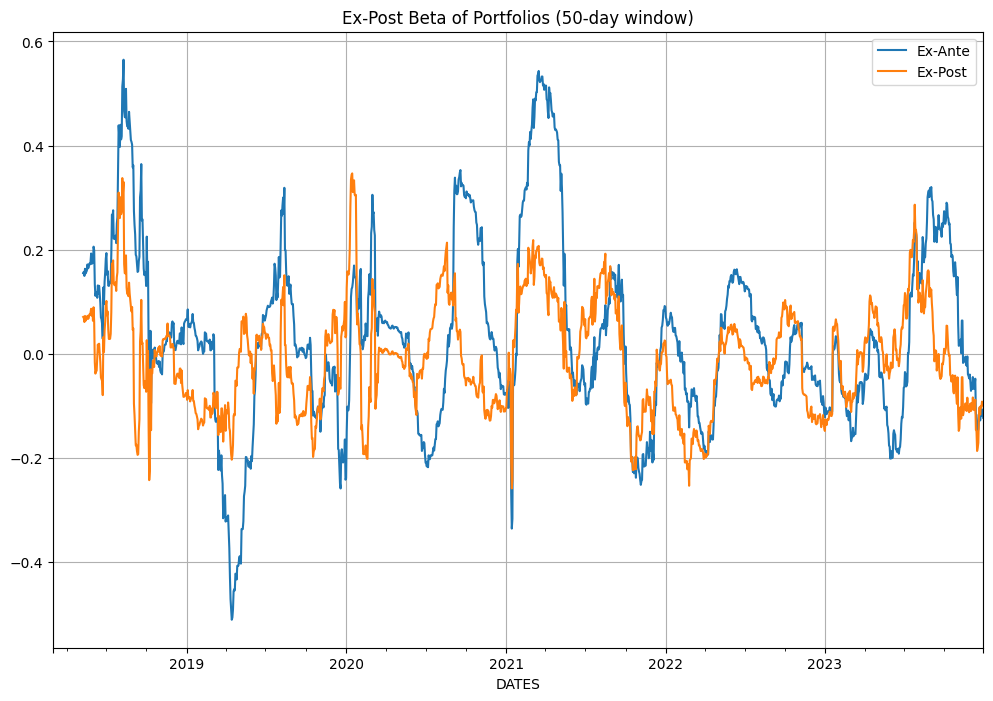

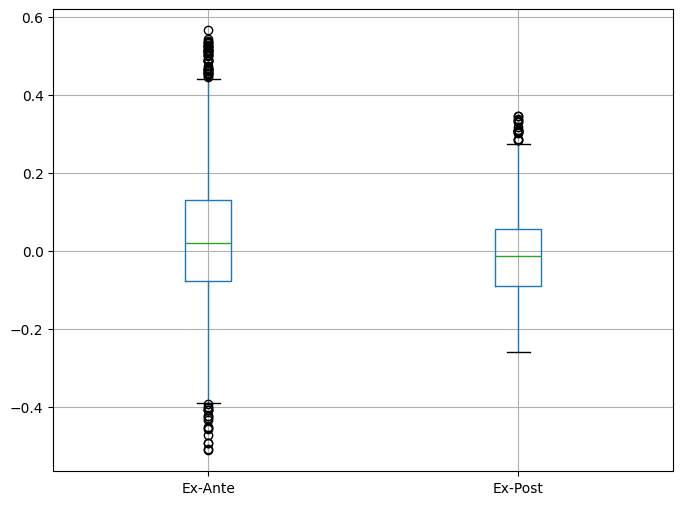

<Axes: xlabel='DATES'>

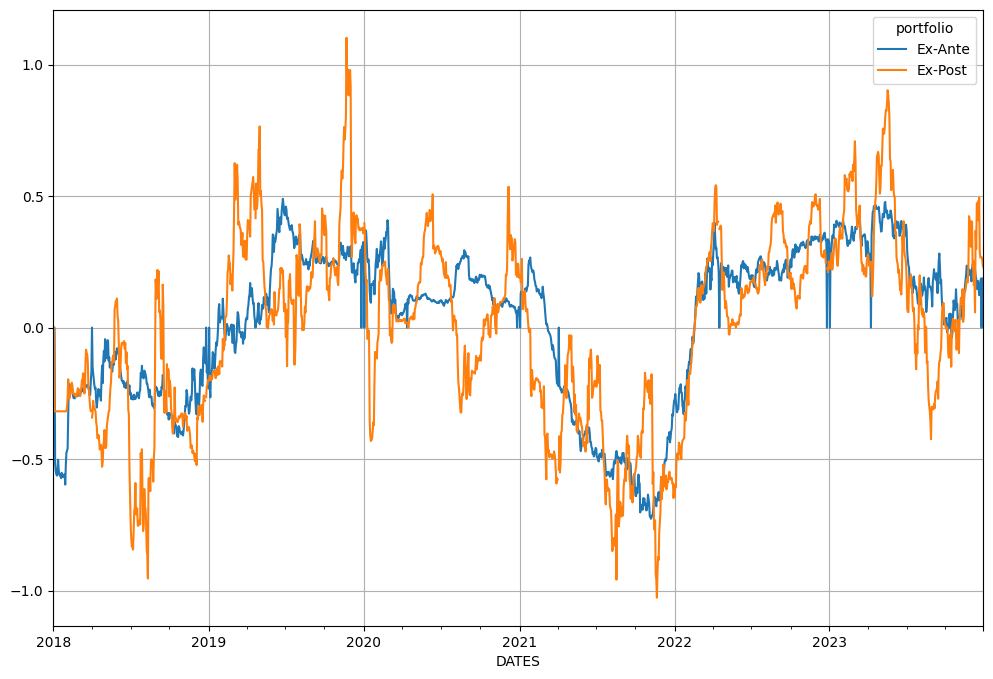

In [19]:
# Plot ex-ante beta through time
df = df_exante_positions
expost_exante_beta = df['Ex-Post'].get_portfolio_exante_beta(df_betas).rename('Ex-Post')
exante_exante_beta = df['Ex-Ante'].get_portfolio_exante_beta(df_betas).rename('Ex-Ante')
df_beta = pd.concat([expost_exante_beta,exante_exante_beta], axis=1)
df_beta.plot(figsize=(12,8), grid=True, title='Ex-Ante Beta of Portfolios')
plt.show()
df_beta.boxplot(figsize=(8,6), grid=True)
plt.show()
 
# Plot ex-post beta through time
df_rolling = df_exante_returns.apply(lambda x: x.get_portfolio_rolling_beta(df_market_returns, window=50))
df_rolling.plot(figsize=(12, 8), grid=True, title='Ex-Post Beta of Portfolios (50-day window)')
plt.show()
df_rolling.boxplot(figsize=(8,6), grid=True)
plt.show()
 
# Plot SPX Index exposure
df_exante_positions.xs(level='security',key='SPX Index', axis=1).plot(figsize=(12,8), grid=True)

### Performance Appraisal: Ex-Ante

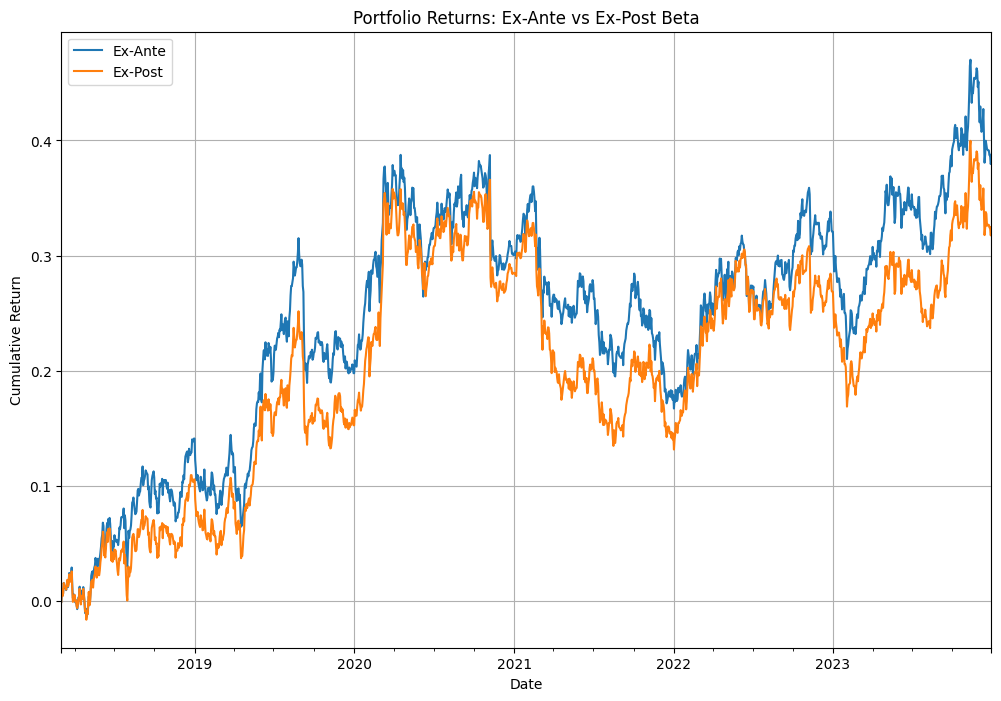

In [20]:
# Plot cumulative returns for ex-ante vs ex-post beta portfolios
df_exante_returns.add(1).cumprod().sub(1).ffill()\
    .plot(figsize=(12, 8),
          title='Portfolio Returns: Ex-Ante vs Ex-Post Beta',
          xlabel='Date',
          ylabel='Cumulative Return',
          grid=True)
plt.show()

In [21]:
# Show performance summary for ex-ante vs ex-post beta portfolios
performance_summary(df_exante_returns, 252, risk_free_rate=0.0, benchmark_r=df_market_returns)

,Ex-Ante,Ex-Post
Annualized Return,0.054904,0.046851
Annualized Volatility,0.107504,0.107221
Skewness,-0.786773,-0.723005
Kurtosis,7.692514,8.847927
Is Normal,False,False
Sharpe Ratio,0.510714,0.436961
Beta to Benchmark,0.028398,-0.019815
Correlation to Benchmark,0.053553,-0.037466
Monthly Historic VaR (95%),0.011161,0.011443
Monthly Historic CVaR (95%),0.01574,0.015496


---

## 4. Biases: Identifying and Neutralizing Sector Biases
Momentum strategies can be unintentionally biased toward certain sectors. Let's identify and address these biases.

In [22]:
# Build sector index for expanded universe
sector_stock_idx = df_stock_returns_raw.columns
sector_stock_idx = sector_stock_idx.append(pd.Index([('IX','SPX Index')]))
sector_stock_idx.names = ['SECTOR', 'TICKER']

In [23]:
# Align ex-ante portfolio positions, mom score, and signal with sector index
df_pf_positions_w_sector = df_exante_positions['Ex-Ante'].rename_axis('TICKER', axis=1).reindex(sector_stock_idx, axis=1, level='TICKER').dropna(how='all',axis=1)
df_stock_mom_score_w_sector = df_stock_mom_score.rename_axis('TICKER', axis=1).reindex(sector_stock_idx, axis=1, level='TICKER').dropna(how='all',axis=1)
df_signal_w_sector = df_signal.rename_axis('TICKER', axis=1).reindex(sector_stock_idx, axis=1, level='TICKER').dropna(how='all',axis=1)

# Calculate sector exposures
df_pf_sector_exp = df_pf_positions_w_sector.T.groupby(level='SECTOR').sum().T.drop('IX', axis=1).loc['2018-03':]
sort_idx = df_pf_sector_exp.mean().sort_values(ascending=False).index

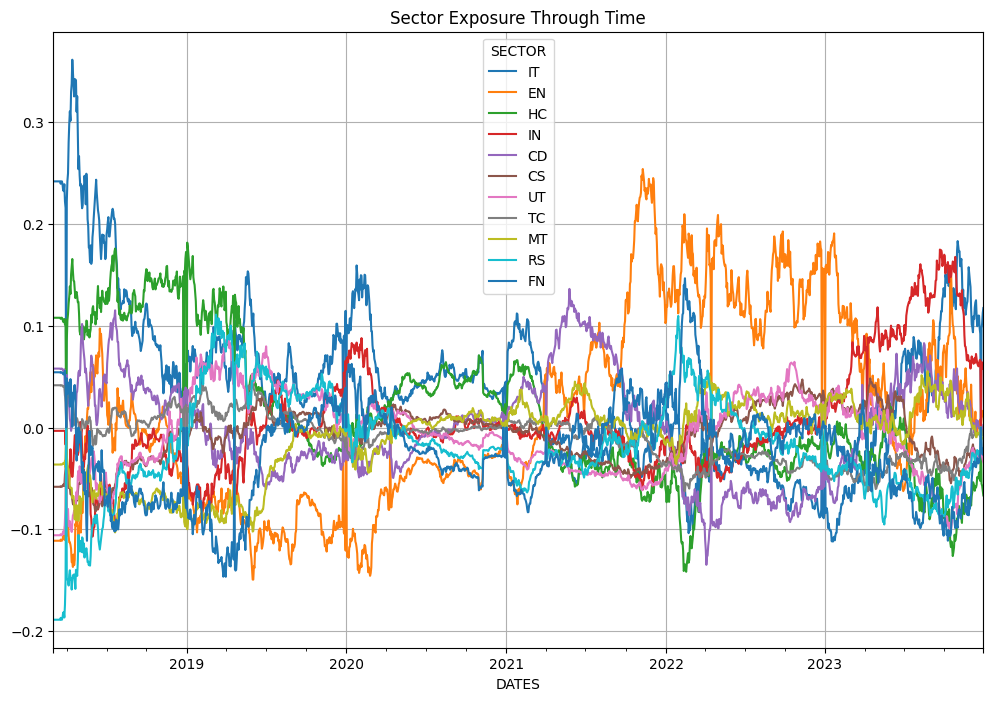

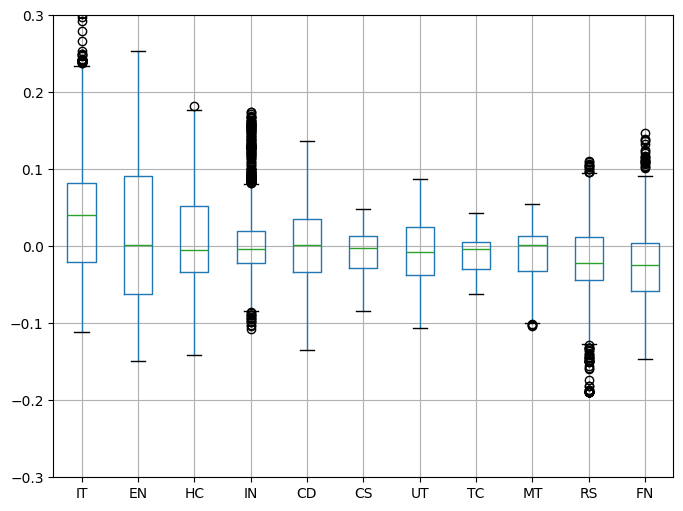

In [24]:
# Visualize sector exposures
df_pf_sector_exp[sort_idx].plot(figsize=(12,8),title='Sector Exposure Through Time', grid=True)
plt.show()
df_pf_sector_exp[sort_idx].boxplot(figsize=(8,6), grid=True)
plt.ylim([-0.3, 0.3])
plt.show()

In [25]:
# Build sector-neutral signals by applying signal generation within each sector
df_signal_sector_neutral = df_stock_mom_score_w_sector.groupby(level='SECTOR', axis=1)\
    .apply(lambda x: x.linear_capped_signals(lower_pct=0.05, upper_pct=0.95).shift(1))\
    .droplevel(0, axis=1)

C:\Users\warnerr\AppData\Local\Temp\ipykernel_27508\709622077.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_signal_sector_neutral = df_stock_mom_score_w_sector.groupby(level='SECTOR', axis=1)\


### Portfolio Construction: Biases

In [26]:
# Build sector-neutral portfolio using sector-neutral signals
sector_neutral_position = position_function(signal_df=df_signal_sector_neutral.droplevel('SECTOR', axis=1), 
                                            returns_df=df_stock_returns, 
                                            market_returns_df=df_market_returns, 
                                            target_vol=0.1, 
                                            dollar_neutral=True, 
                                            beta_neutral=True, 
                                            max_gearing=1.25, 
                                            max_posn=None, 
                                            window=40, 
                                            beta_type='exante', 
                                            asset_betas=df_betas)


# Compare ex-ante and ex-post beta portfolios
df_bias_positions = pd.concat({'Sector Biased': exante_beta_position,
                               'Sector Neutral': sector_neutral_position
                                 }, axis=1).rename_axis(['portfolio','security'], axis=1)
 
# Compute returns for each portfolio 
df_bias_returns = pd.DataFrame()
for pf in df_bias_positions.columns.get_level_values('portfolio').unique():
    df_bias_returns[pf] = df_bias_positions[pf].get_portfolio_returns(df_returns)
df_bias_returns = df_bias_returns.loc['2018-03':]

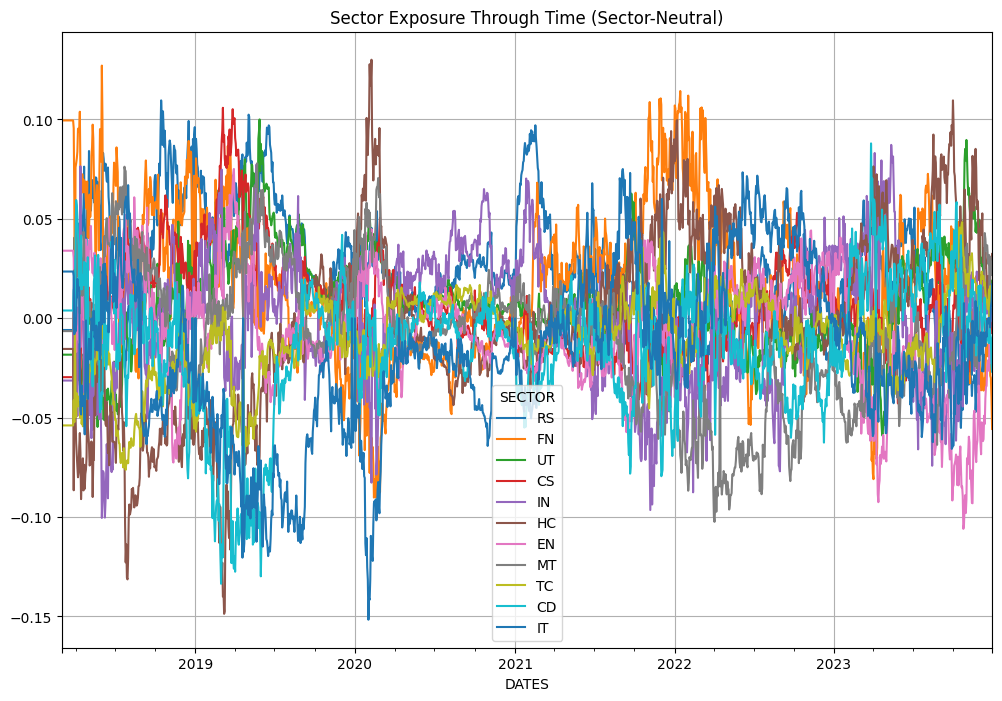

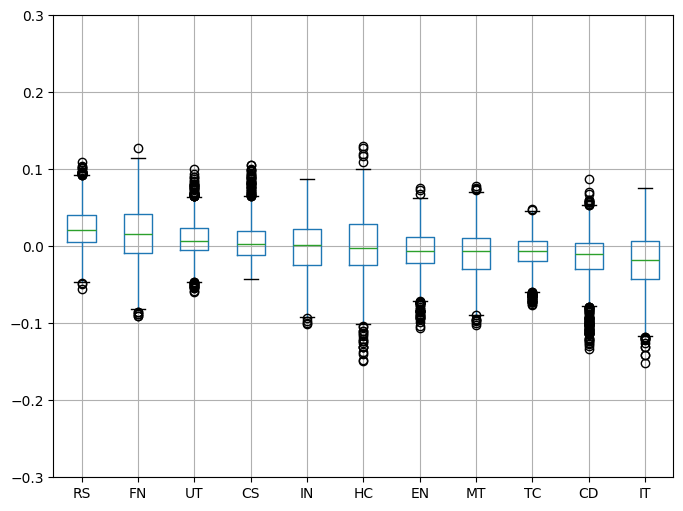

In [27]:
# Visualize sector exposures after sector-neutralization
df_pf_positions_wo_sector_bias = sector_neutral_position.rename_axis('TICKER', axis=1).reindex(sector_stock_idx, axis=1, level='TICKER').dropna(how='all',axis=1)
df_pf_wo_sector_exp_bias = df_pf_positions_wo_sector_bias.T.groupby(level='SECTOR').sum().T.drop('IX', axis=1).loc['2018-03':]
sort_idx_bias = df_pf_wo_sector_exp_bias.mean().sort_values(ascending=False).index

df_pf_wo_sector_exp_bias[sort_idx_bias].plot(figsize=(12,8),title='Sector Exposure Through Time (Sector-Neutral)', grid=True)
plt.show()
df_pf_wo_sector_exp_bias[sort_idx_bias].boxplot(figsize=(8,6))
plt.ylim([-0.3, 0.3])
plt.show()

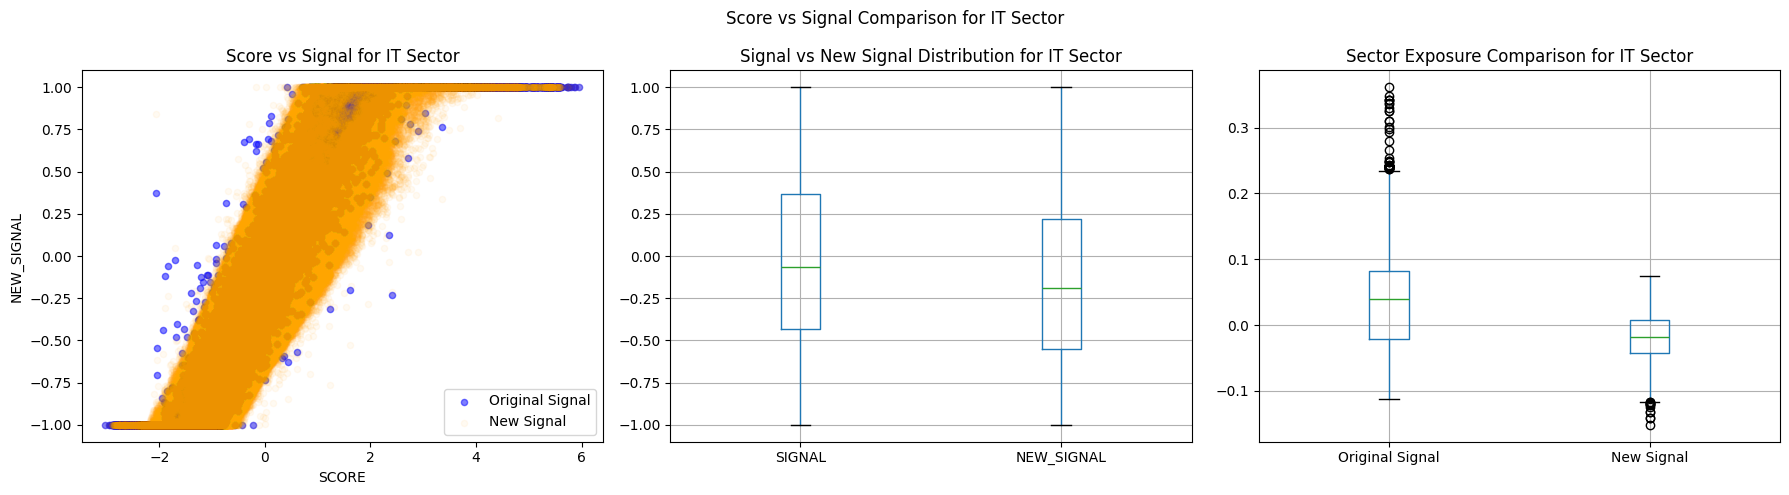

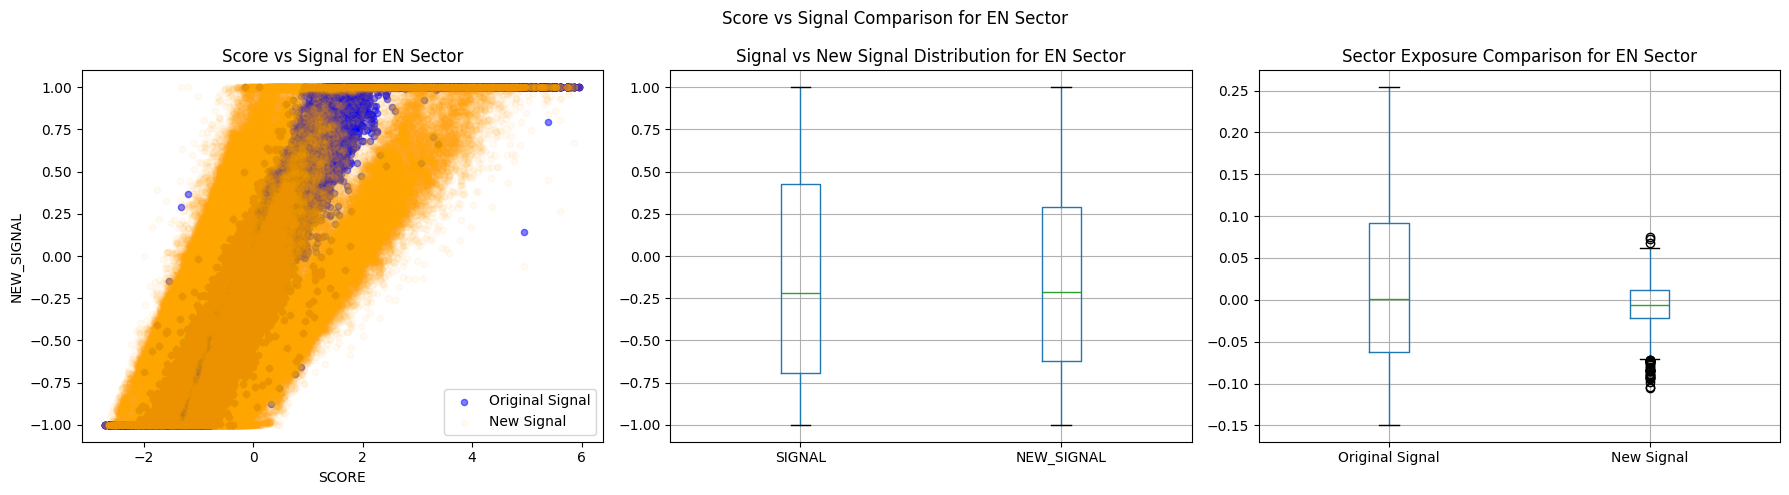

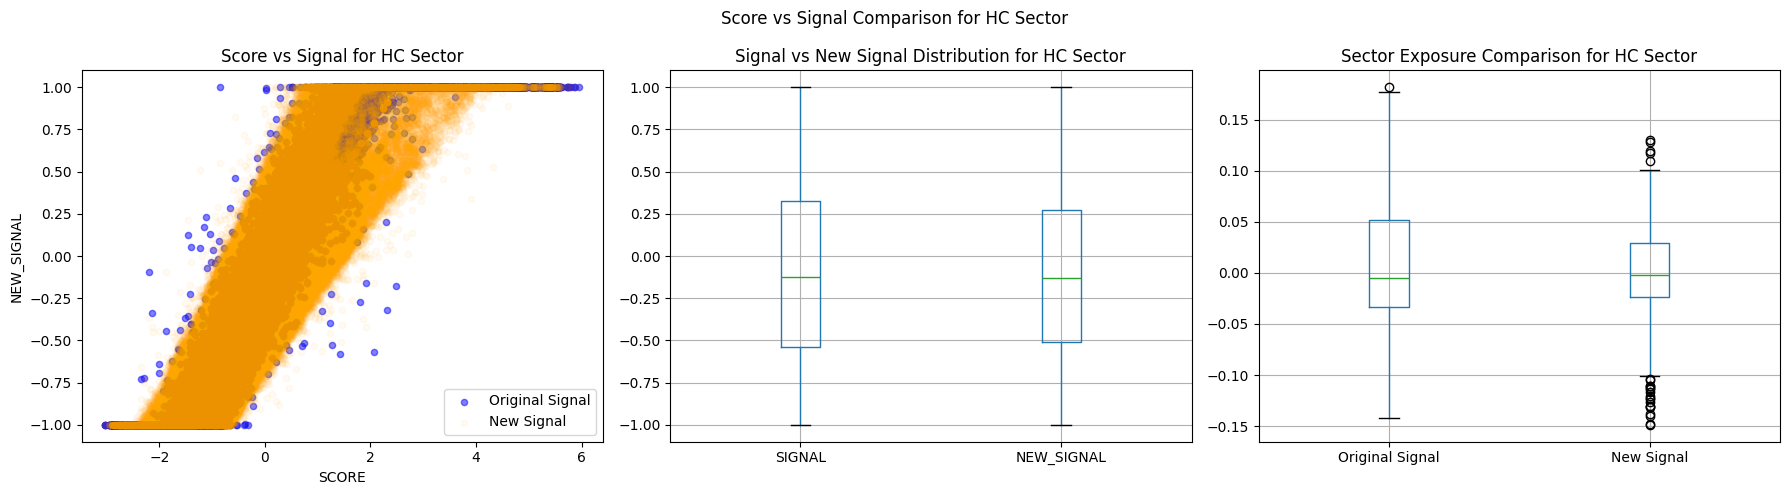

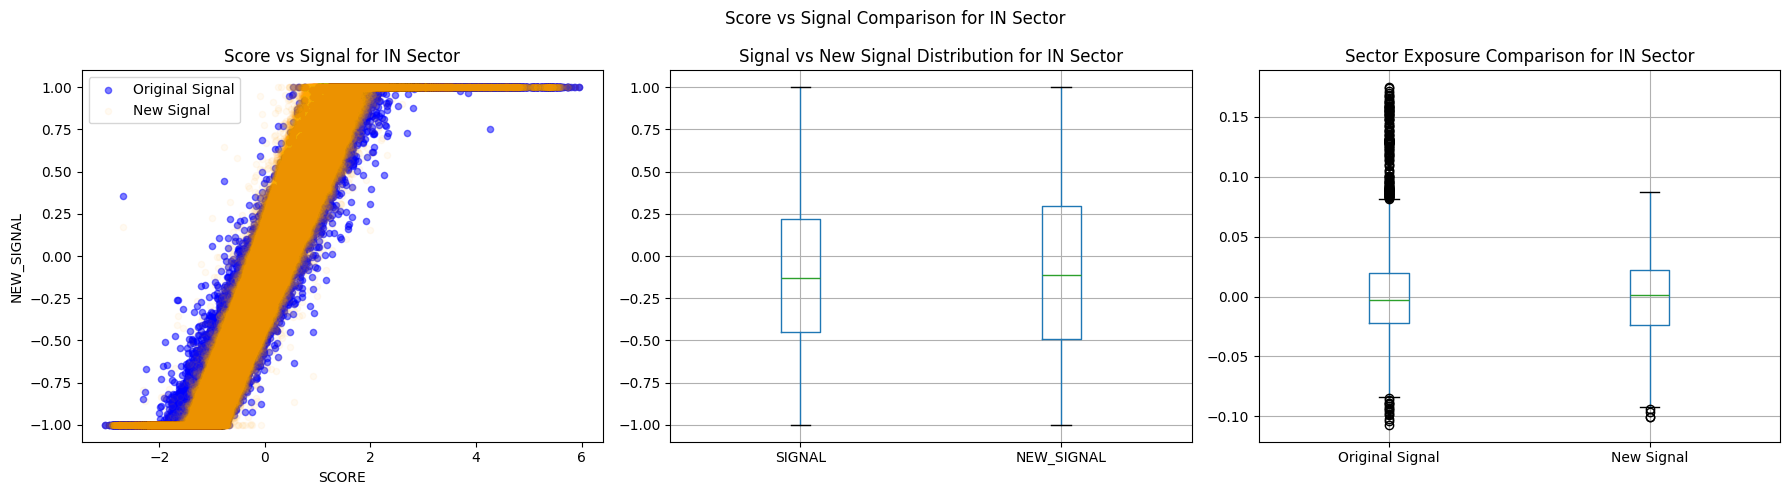

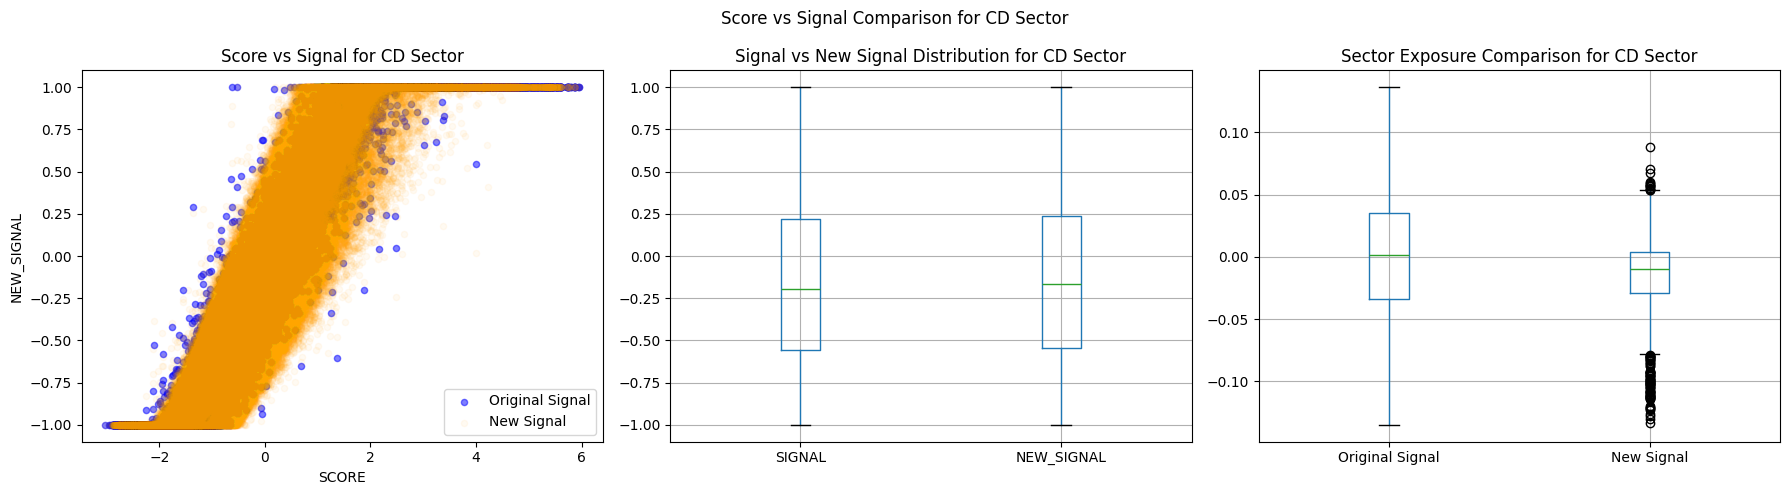

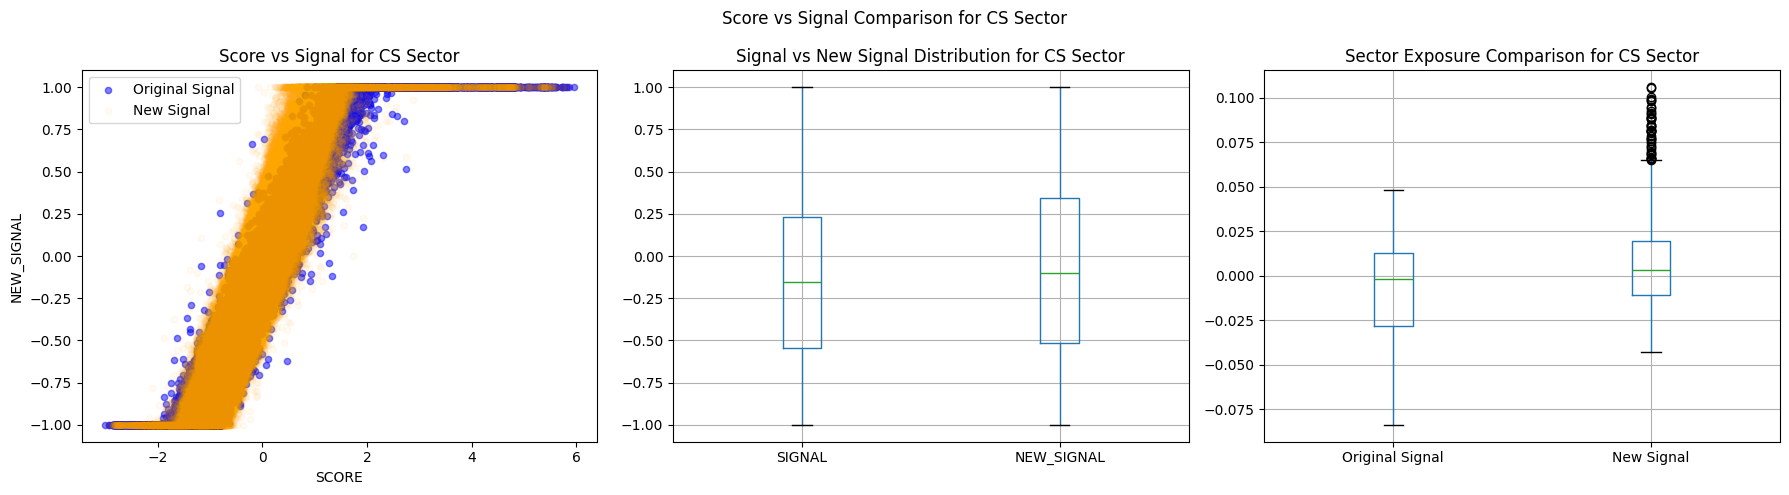

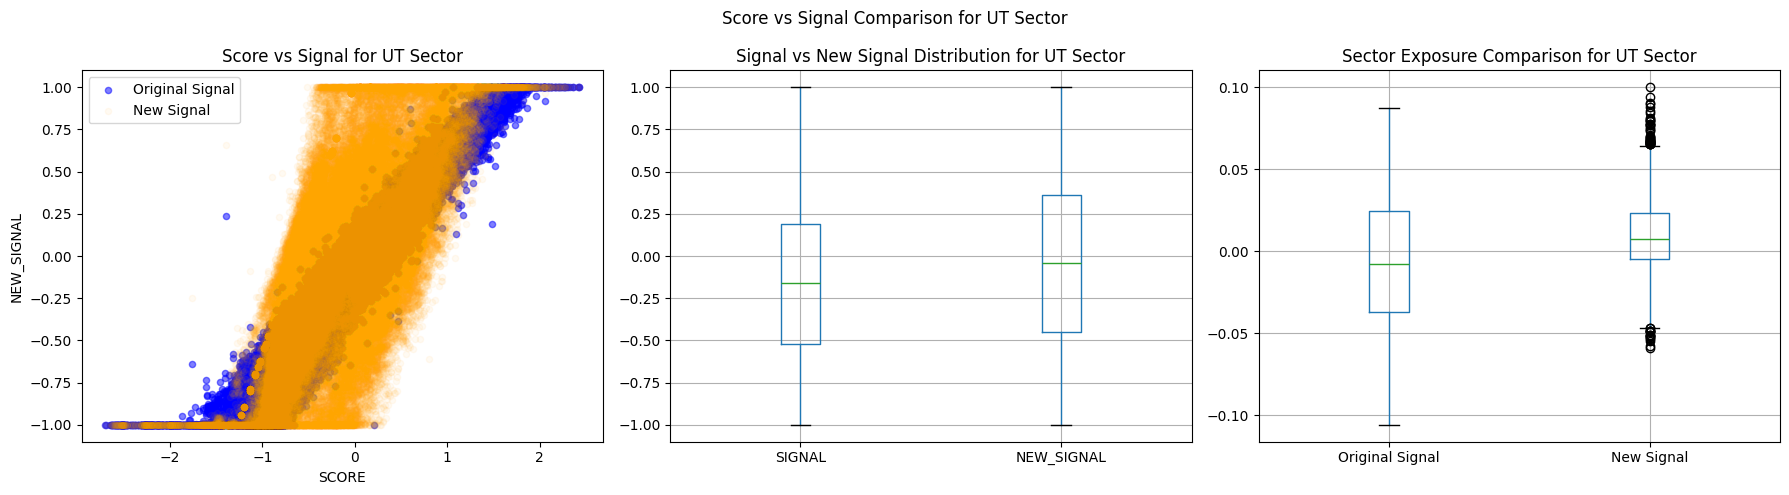

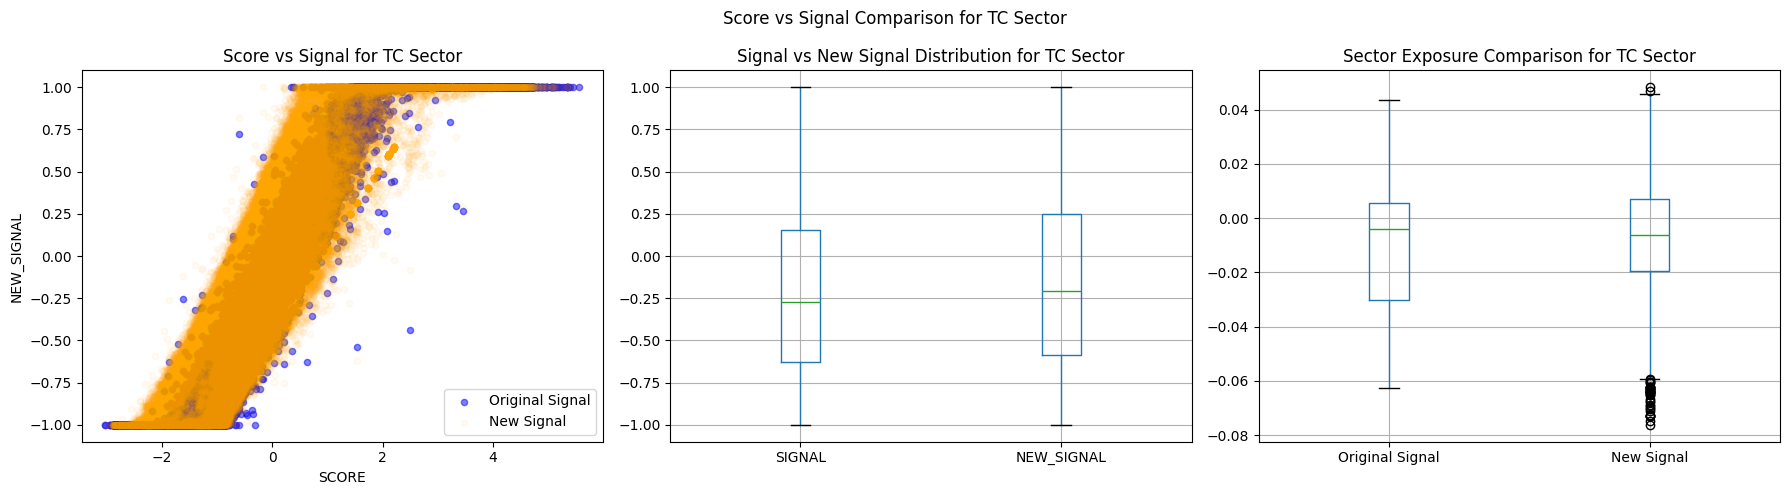

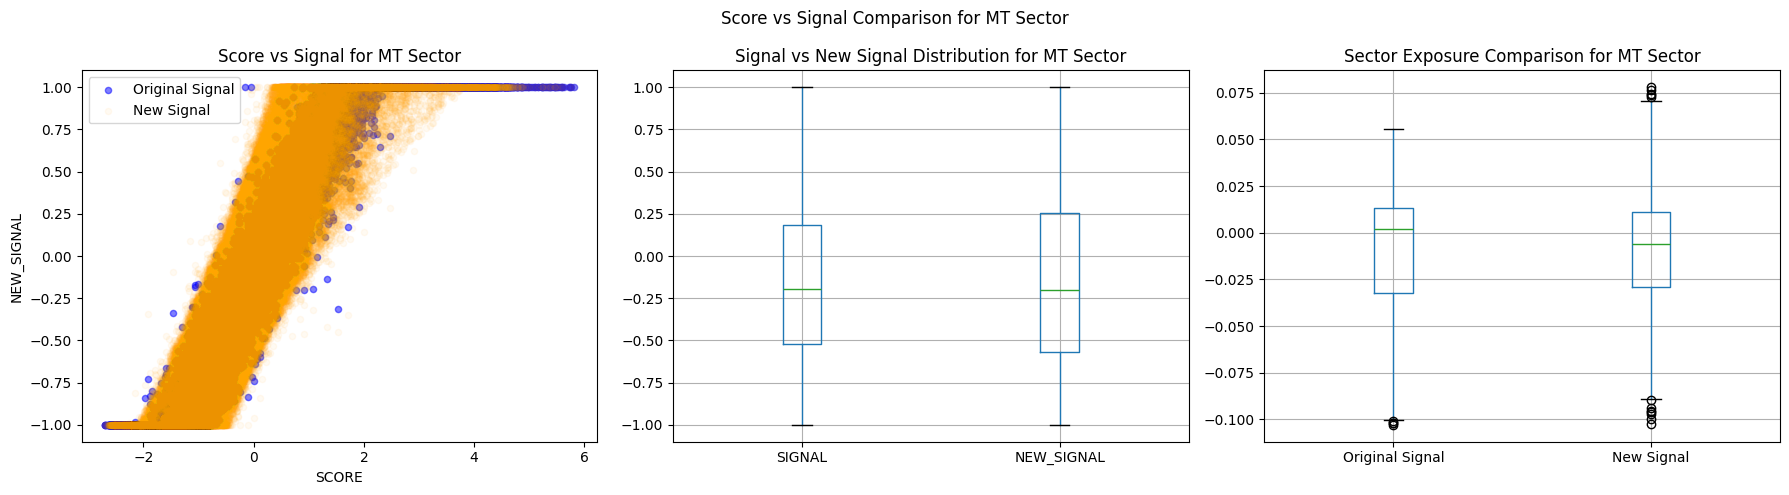

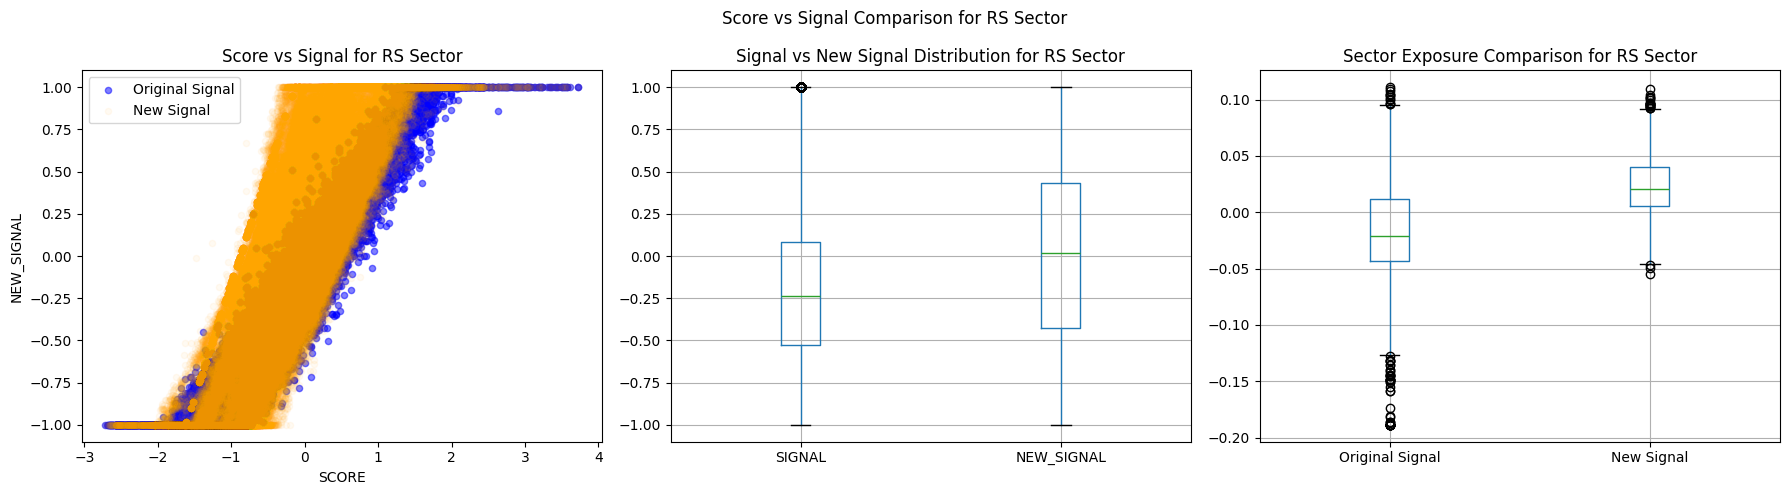

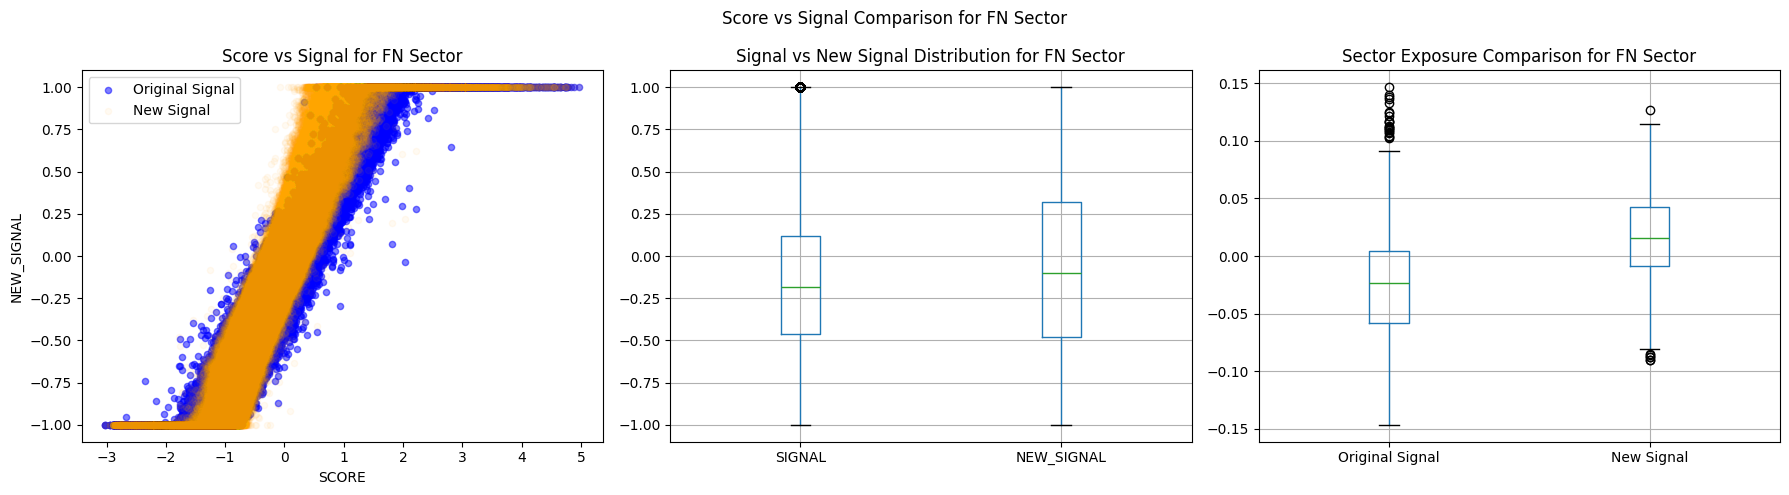

In [35]:
# Compare original and sector-neutral signals and exposures for each sector
for sector in sort_idx:
    df_score = df_stock_mom_score_w_sector[sector].stack().rename('SCORE')
    df_orig_signal = df_signal_w_sector[sector].stack().rename('SIGNAL')
    df_new_signal = df_signal_sector_neutral[sector].stack().rename('NEW_SIGNAL')
    df_combined = pd.concat([df_score, df_orig_signal, df_new_signal], axis=1)
    fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(18, 5))
    df_combined.plot.scatter(x='SCORE', y='SIGNAL', alpha=0.5, title=f'Score vs Signal for {sector} Sector', ax=ax[0], color='blue')
    df_combined.plot.scatter(x='SCORE', y='NEW_SIGNAL', alpha=0.05, ax=ax[0], color='orange')
    ax[0].legend(['Original Signal', 'New Signal'])
    
    df_combined[['SIGNAL','NEW_SIGNAL']].boxplot(ax=ax[1], grid=True)
    ax[1].set_title(f'Signal vs New Signal Distribution for {sector} Sector')

    df_exp_combined = pd.concat([df_pf_sector_exp[sector].rename('Original Signal'), df_pf_wo_sector_exp_bias[sector].rename('New Signal')], axis=1)
    df_exp_combined.boxplot(ax=ax[2], grid=True)
    ax[2].set_title(f'Sector Exposure Comparison for {sector} Sector')
    
    plt.suptitle(f'Score vs Signal Comparison for {sector} Sector')
    plt.tight_layout()
    plt.show()

### Performance Appraisal: Biases

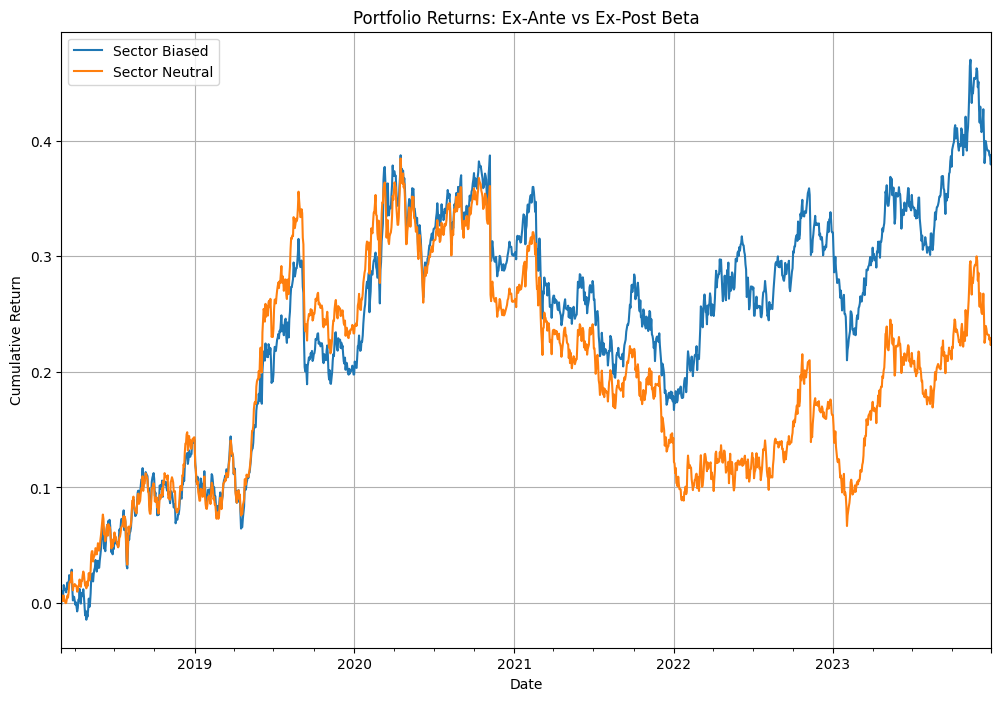

In [29]:
# Plot cumulative returns for ex-ante vs ex-post beta portfolios
df_bias_returns.add(1).cumprod().sub(1).ffill()\
    .plot(figsize=(12, 8),
          title='Portfolio Returns: Ex-Ante vs Ex-Post Beta',
          xlabel='Date',
          ylabel='Cumulative Return',
          grid=True)
plt.show()

In [30]:
# Show performance summary for ex-ante vs ex-post beta portfolios
performance_summary(df_bias_returns, 252, risk_free_rate=0.0, benchmark_r=df_market_returns)

,Sector Biased,Sector Neutral
Annualized Return,0.054904,0.034236
Annualized Volatility,0.107504,0.10761
Skewness,-0.786773,-1.041167
Kurtosis,7.692514,11.127148
Is Normal,False,False
Sharpe Ratio,0.510714,0.318153
Beta to Benchmark,0.028398,0.023978
Correlation to Benchmark,0.053553,0.045172
Monthly Historic VaR (95%),0.011161,0.011231
Monthly Historic CVaR (95%),0.01574,0.01584


### Issues with the above

While it looks like we have made the portfolio worse based on performance alone, remember there is an inherent bias in our backtest period: tech did very well!

However, our solution is not free from issues. One thing to think about is risk contributions. While we have neutralized (and in some ways equalized) biased net exposures to each of the sectors, the risk contribution from each sector is by no means equal. As an exercise to the reader, I would ask them to measure sector risk contribution through time, and think of how to account for this.

---
# Key Takeaways & Next Steps

- **Expanding the universe** improved diversification and risk-adjusted returns.
- **Ex-ante beta** provided more stable risk control than ex-post regression.
- **Sector-neutralization** removed hidden biases and made the portfolio more robust.

**Next steps:**
- Explore other risk models (e.g., multi-factor, volatility targeting)
- Test out-of-sample and in different market regimes
- Consider transaction costs and implementation details

Thank you for participating! Questions and discussion welcome.